In [1]:
""" import useful functions """
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

# Generic
import numpy as np
import pandas as pd
import scipy
from itertools import islice, cycle
import math
import os
import sys
from scipy.integrate import odeint
#from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
from scipy.interpolate import interpn
from scipy.interpolate import CubicSpline
import gc
from scipy.signal import savgol_filter

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
import sacc
import time

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib
#from tabulate import tabulate
from matplotlib.colors import LogNorm
#import seaborn as sns

# Parallelising 
from multiprocessing import Pool
import multiprocessing

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import corner
#from chainconsumer import ChainConsumer, Chain, make_sample
from IPython.display import display, Math
from multiprocessing import Pool
#from tqdm import tqdm

# HiCOLA background
from HiCOLA.Frontend import expression_builder as eb
import HiCOLA.Frontend.numerical_solver as ns
from HiCOLA.Frontend.read_parameters import read_in_parameters
import sympy as sym


In [2]:
# Cubic Galileon emu and background
from CubicGalileonEmu.load import *
from CubicGalileonEmu.viz import *
from CubicGalileonEmu.pca import *
from CubicGalileonEmu.gp import *
from CubicGalileonEmu.emu import *
from CubicGalileonEmu.mcmc import *


if_train_all = False ## Re-train all the models. Time-consuming. 
if_mcmc_all = False  ## Full MCMC run. Time-consuming. 
if_savefig = False

from configobj import ConfigObj
import subprocess

In [3]:
cosmo_testing = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9)

In [4]:
# Loading CuGal files

Bk_all, Bk_all_smooth, k_all, z_all = load_boost_data()
Bk_lin_all, _, _ = load_boost_data_lin()
p_all = load_params()

print(p_all.shape, flush=True)

## Data prep
z_index = 1

y_vals = Bk_all[:, z_index, :]

# y_ind = np.arange(0, y_vals.shape[1])
y_ind = k_all

# Load validation data

Bk_all_val, Bk_lin_all_val, _, _ = load_boost_data(LIBRARY_BK_FILE_VAL, LIBRARY_ZK_FILE_VAL)
target_vals = Bk_all_val[:, z_index, :]
input_params = load_params(LIBRARY_PARAM_FILE_VAL)

train_indices = [i for i in np.arange(49)] # if i not in test_indices]
print(train_indices, flush=True)

p_all_train = p_all[train_indices]
y_vals_train = Bk_all[:, z_index, :][train_indices]

sepia_data = sepia_data_format(p_all_train, y_vals_train, y_ind)
print(sepia_data)
model_filename = '/global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/multivariate_model_z_index' + str(z_index) 

#sepia_model = do_pca(sepia_data, exp_variance=0.95)
#sepia_model = do_gp_train(sepia_model, model_filename)
#plot_train_diagnostics(sepia_model)

if if_train_all:
    
    do_gp_train_multiple(model_dir='/global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/', 
                        p_train_all = p_all[train_indices],
                        y_vals_all = Bk_all_smooth[train_indices],
                        y_ind_all = k_all,
                        z_index_range=range(49))

sepia_model_list, sepia_data_list = load_model_multiple(model_dir='/global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/', 
                                        p_train_all=p_all[train_indices],
                                        y_vals_all=Bk_all_smooth[train_indices],
                                        y_ind_all=k_all,
                                        z_index_range=range(50))



(50, 5)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
This SepiaData instance implies the following:
This is a simulator (eta)-only model, y dimension 768
m  =    49 (number of simulated data)
p  =     1 (number of inputs)
q  =     5 (number of additional simulation inputs)
pu NOT SET (transformed response dimension); call method create_K_basis 

Number of models loaded: 50 from: /global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/


In [5]:
# NL matter power spectra in fR
def P_k_NL_CuGal(GR_pk2D_obj, f_phi, cosmo, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """
    if isinstance(a, (float, int)):  # Single scale factor case
        input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            1.0 / a - 1.0
        )
        bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
        interp_func = scipy.interpolate.interp1d(k_all * cosmo["h"], bk_target.flatten(), kind='linear', fill_value="extrapolate")
        pkratio_CuGal = interp_func(k)
        
    else:
        bk_target = []
        z_range = 1.0 / a - 1.0  # Array of redshift values

        # Loop over each redshift value
        for z_val in z_range:
            input_params_and_redshift = np.append(
                np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
                z_val
            )
            bk_target_i, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
            bk_target.append(bk_target_i.flatten()) 
    
        # Convert list to array with shape (len(a), len(k_all))
        bk_target = np.array(bk_target)

        
        # Interpolating each row in bk_target over k
        pkratio_CuGal = np.array([
            scipy.interpolate.interp1d(k_all * cosmo["h"], bk_row, kind='linear', fill_value="extrapolate")(k) 
            for bk_row in bk_target
        ])
    

    Pk_ccl = GR_pk2D_obj.__call__(k, a=a) # units (Mpc)^3
    Pk = pkratio_CuGal*Pk_ccl
    
    return Pk

In [6]:
# NL matter power spectra in fR
def B_k_NL_CuGal(f_phi, cosmo, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """
    if isinstance(a, (float, int)):  # Single scale factor case
        input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            1.0 / a - 1.0
        )
        bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
        interp_func = scipy.interpolate.interp1d(k_all * cosmo["h"], bk_target.flatten(), kind='linear', fill_value="extrapolate")
        pkratio_CuGal = interp_func(k)
        
    else:
        bk_target = []
        z_range = 1.0 / a - 1.0  # Array of redshift values

        # Loop over each redshift value
        for z_val in z_range:
            input_params_and_redshift = np.append(
                np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
                z_val
            )
            bk_target_i, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
            bk_target.append(bk_target_i.flatten()) 
    
        # Convert list to array with shape (len(a), len(k_all))
        bk_target = np.array(bk_target)

        # Interpolating each row in bk_target over k
        pkratio_CuGal = np.array([
            scipy.interpolate.interp1d(k_all * cosmo["h"], bk_row, kind='linear', fill_value="extrapolate")(k) 
            for bk_row in bk_target
        ])
    

    
    return pkratio_CuGal

In [7]:
"""Linear matter power spectra CuGal"""

def P_k_CuGal_lin(GR_pk2D_obj,f_phi, cosmo, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """

    input_params_and_redshift = np.append(np.array([cosmo["Omega_m"],cosmo["n_s"],1e9*cosmo["A_s"],cosmo["h"],f_phi]) , 1.0/a -1.0)     
    bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
    
    pkratio_CuGal = bk_target[0]

    Pk_ccl = GR_pk2D_obj.__call__(k, a=a) # units (Mpc)^3
    Pk = pkratio_CuGal*Pk_ccl

    return Pk


def Get_Pk2D_obj_kk_GR_nl(cosmo):
   
    ########### Functions for linear matter power spectrum multiplied by Sigma**2 ###########        
    def pk_funcSigma2(k, a):
        return ccl.nonlin_matter_power(cosmo, k=k, a=a)

    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_funcSigma2, is_logp=False)
    

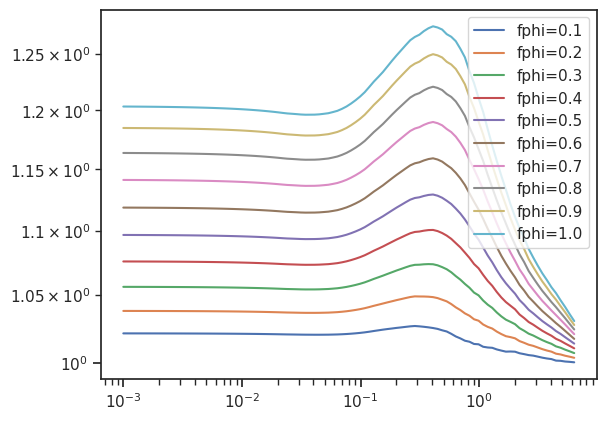

In [8]:
# Example test case

cosmo_testing = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9)


P_delta2D_GR_nl_test = Get_Pk2D_obj_kk_GR_nl(cosmo_testing)

a_test = 1
k_test = np.logspace(-3,0.8,100)
f_phi_range = np.linspace(0.1,1.0,10)
for i in range(len(f_phi_range)):
    BkTest_new = B_k_NL_CuGal(f_phi_range[i], cosmo_testing, k_test, a_test)

    plt.loglog(k_test, BkTest_new, label=f"fphi={f_phi_range[i]:.1f}")
plt.legend()
plt.show()

## Validation with the data itself

In [19]:
# Load the saved array - gives Boost(i = sample point, z, k)
#Bk_arr_val = np.load('Validation_data/Boost_validation.npy')
Bk_arr_val = np.load('Validation_data/Boost.npy')
print(Bk_arr_val.shape)
# extract data from text file - gives z and k arrays
txt_arr_val = np.loadtxt("Validation_data/z_k.txt")

z_arr_val = np.array(txt_arr_val.T[0][np.isfinite(txt_arr_val.T[0])])
k_arr_val = np.array(txt_arr_val.T[1])

print(z_arr_val.shape)
print(k_arr_val.shape)

# Get the parameter - for now assume only one parameter, w_m
txt = "Validation_data/cosmo_newdesign_tracker"
hcube_val  = np.loadtxt(txt).T
f_phi_val = hcube_val[4]
h_val = hcube_val[3]
Omega_m_val = hcube_val[0]
n_s_val = hcube_val[1]
A_s_val = hcube_val[2]



(50, 51, 768)
(51,)
(768,)


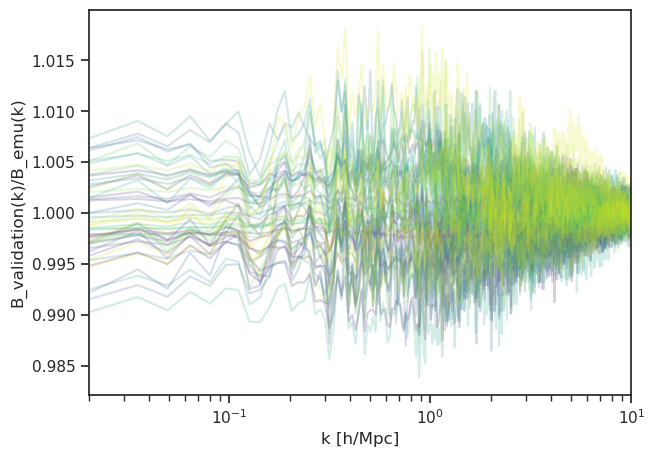

In [20]:
f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val)):
    
    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    ax.plot(k_arr_val, Bk_arr_val[sim_index, 0, :]/Bk_test_val,color = cmap(np.linspace(0,1,len(f_phi_val))[sim_index]), alpha=0.2)

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


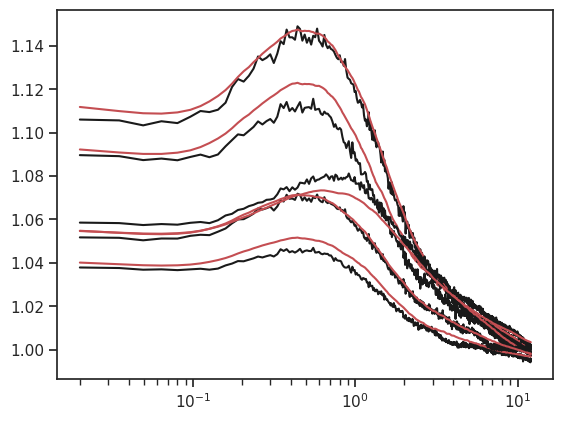

In [21]:

for sim_index in range(5):

    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    plt.semilogx(k_arr_val, Bk_arr_val[sim_index, 0, :], color="k")
    plt.semilogx(k_arr_val, Bk_test_val, color="r")

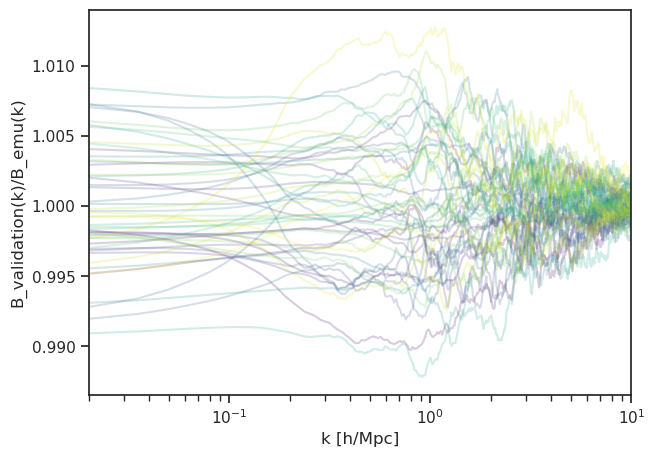

In [22]:
## With smoothing

f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val)):
    
    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    ax.plot(k_arr_val, savgol_filter(Bk_arr_val[sim_index, 0, :], 17,3)/Bk_test_val,color = cmap(np.linspace(0,1,len(f_phi_val))[sim_index]), alpha=0.2)

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


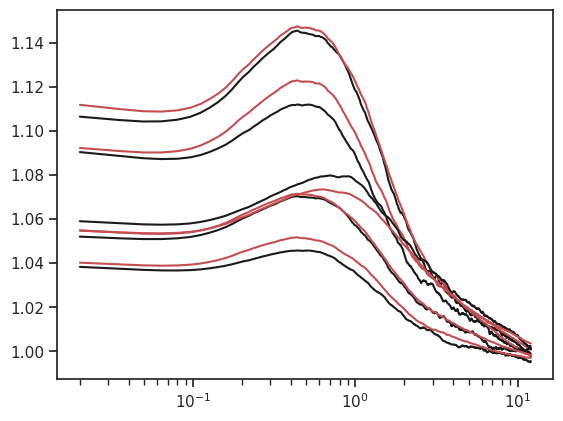

In [23]:
## With smoothing



for sim_index in range(5):

    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    plt.semilogx(k_arr_val, savgol_filter(Bk_arr_val[sim_index, 0, :], 17,3), color="k")
    plt.semilogx(k_arr_val, Bk_test_val, color="r")

## Validation set 1

In [32]:
# Load the saved array - gives Boost(i = sample point, z, k)
#Bk_arr_val = np.load('Validation_data/Boost_validation.npy')
Bk_arr_val = np.load('Validation_data/Boost_validation.npy')
print(Bk_arr_val.shape)
# extract data from text file - gives z and k arrays
txt_arr_val = np.loadtxt("Validation_data/z_k_validation.txt")

z_arr_val = np.array(txt_arr_val.T[0][np.isfinite(txt_arr_val.T[0])])
k_arr_val = np.array(txt_arr_val.T[1])

print(z_arr_val.shape)
print(k_arr_val.shape)

# Get the parameter - for now assume only one parameter, w_m
txt = "Validation_data/cosmo_validation"
hcube_val  = np.loadtxt(txt).T
f_phi_val = hcube_val[4]
h_val = hcube_val[3]
Omega_m_val = hcube_val[0]
n_s_val = hcube_val[1]
A_s_val = hcube_val[2]

print(f_phi_val[0],f_phi_val[24])

(25, 101, 768)
(101,)
(768,)
0.03 0.99


In [33]:
print(hcube_val[0])

[0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321
 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321 0.321
 0.321]


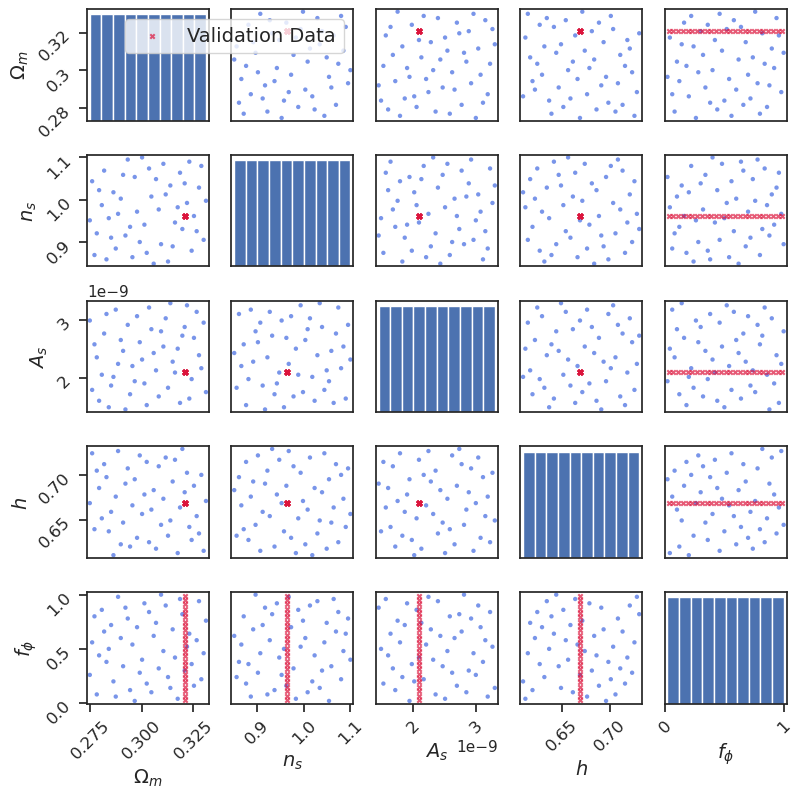

In [34]:
txt = "Validation_data/cosmo_newdesign_tracker"
hcube_emu  = np.loadtxt(txt)
txt = "Validation_data/cosmo_validation"
hcube_val  = np.loadtxt(txt)

# Sample DataFrames (replace with actual data)
df_theta_emu = pd.DataFrame(hcube_emu, columns=[r'$\Omega_m$', r'$n_s$', r'$A_s$', r'$h$', r'$f_\phi$'][:len(hcube_emu)])
df_theta_val = pd.DataFrame(hcube_val, columns=[r'$\Omega_m$', r'$n_s$', r'$A_s$', r'$h$', r'$f_\phi$'][:len(hcube_val)])

# Customization options
color_emu = "royalblue"   # Color for df_theta_emu
color_val = "crimson"     # Color for df_theta_val
s = 10                    # Marker size
tick_size = 12            # Tick label size
label_size = 14           # Axis label size
tick_rotation = 45        # Rotation angle for tick labels
diag_color = "black"      # Color for diagonal histograms/KDE

# Create scatter matrix for the first dataset
scatter_matrix_fig = pd.plotting.scatter_matrix(
    df_theta_emu, 
    figsize=(8, 8), 
    color=color_emu, 
    marker='o', 
    s=s, 
    alpha=0.7,
    density_kwds={'color': diag_color, 'linewidth': 2},
)

# Overlay the second dataset
for i in range(len(df_theta_emu.columns)):
    for j in range(len(df_theta_emu.columns)):
        if i != j:  # Only apply to scatter plots, not the diagonal
            ax = scatter_matrix_fig[i, j]
            ax.scatter(df_theta_val.iloc[:, j], df_theta_val.iloc[:, i], color=color_val, marker='x', s=s, alpha=0.7, label="Validation Data")

# Customize tick labels and labels
plt.tight_layout()
for ax in plt.gcf().get_axes():
    ax.tick_params(axis="both", labelsize=tick_size, rotation=tick_rotation)
    ax.xaxis.label.set_size(label_size)
    ax.yaxis.label.set_size(label_size)

# Add legend to one of the subplots
scatter_matrix_fig[0, 1].legend(loc="upper right", fontsize=label_size)

plt.show()


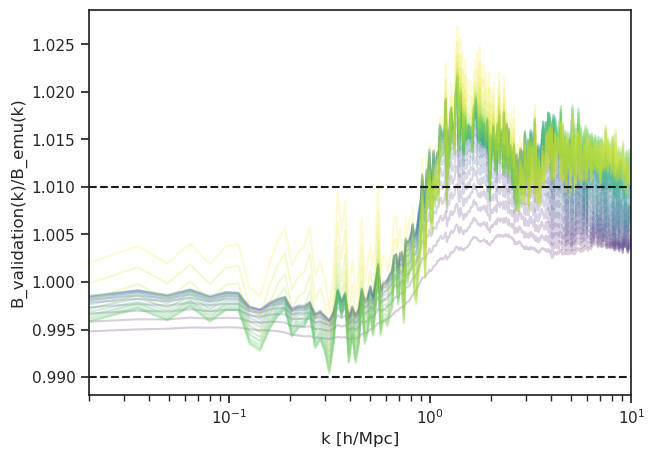

In [35]:
f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val)):
    
    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    ax.plot(k_arr_val, Bk_arr_val[sim_index, 0, :]/Bk_test_val,color = cmap(np.linspace(0,1,len(f_phi_val))[sim_index]), alpha=0.2)

ax.plot(k_arr_val, 1.01*np.ones(len(k_arr_val)), "k--")
ax.plot(k_arr_val, 0.99*np.ones(len(k_arr_val)), "k--")

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


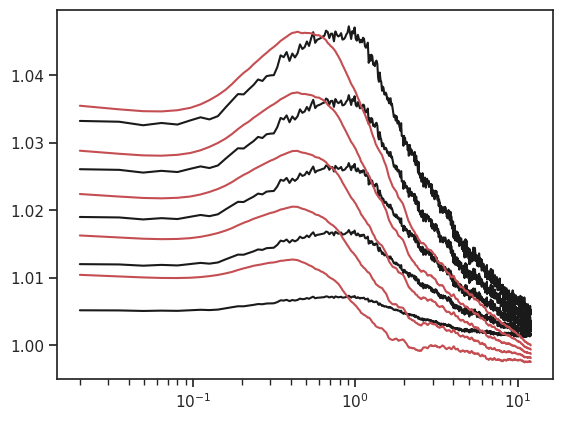

In [36]:

for sim_index in range(5):

    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    plt.semilogx(k_arr_val, Bk_arr_val[sim_index, 0, :], color="k")
    plt.semilogx(k_arr_val, Bk_test_val, color="r")

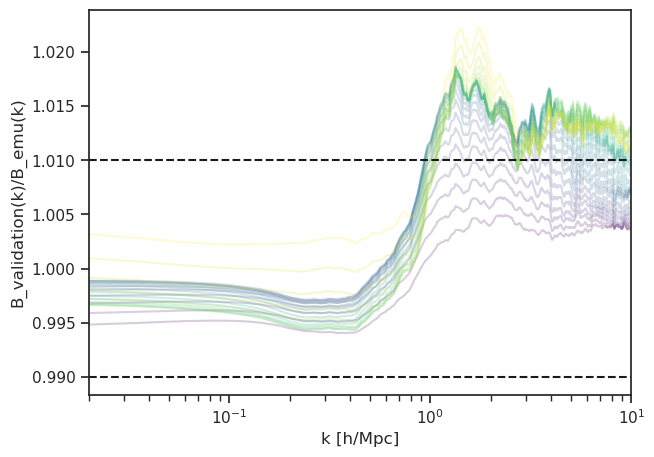

In [37]:
## With smoothing

f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val)):
    
    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    ax.plot(k_arr_val, savgol_filter(Bk_arr_val[sim_index, 0, :], 17,3)/Bk_test_val,color = cmap(np.linspace(0,1,len(f_phi_val))[sim_index]), alpha=0.2)


ax.plot(k_arr_val, 1.01*np.ones(len(k_arr_val)), "k--")
ax.plot(k_arr_val, 0.99*np.ones(len(k_arr_val)), "k--")

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


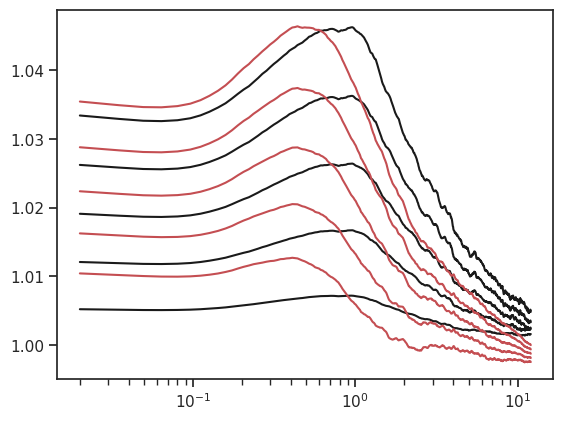

In [38]:
## With smoothing



for sim_index in range(5):

    cosmo_val = ccl.Cosmology(Omega_c = Omega_m_val[sim_index] - 0.0223/h_val[sim_index]**2,
                               Omega_b = 0.0223/h_val[sim_index]**2,
                               h = h_val[sim_index],
                               n_s = n_s_val[sim_index],
                               A_s = A_s_val[sim_index])
    
    Bk_test_val = B_k_NL_CuGal(f_phi_val[sim_index], cosmo_val, k_arr_val*cosmo_val["h"], 1)

    plt.semilogx(k_arr_val, savgol_filter(Bk_arr_val[sim_index, 0, :], 17,3), color="k")
    plt.semilogx(k_arr_val, Bk_test_val, color="r")

## Validation set 2

In [47]:
# Load the saved array - gives Boost(i = sample point, z, k)
Bk_arr_val_edges = np.load('Validation_data/Boost_validation_edges.npy')
print(Bk_arr_val_edges.shape)
# extract data from text file - gives z and k arrays
txt_arr_val_edges = np.loadtxt("Validation_data/z_k_validation_edges.txt")

z_arr_val_edges = np.array(txt_arr_val_edges.T[0][np.isfinite(txt_arr_val_edges.T[0])])
k_arr_val_edges = np.array(txt_arr_val_edges.T[1])

print(z_arr_val_edges.shape)
print(k_arr_val_edges.shape)

# Get the parameter - for now assume only one parameter, w_m
txt = "Validation_data/cosmo_validation_edges"
hcube_val_edges  = np.loadtxt(txt).T
f_phi_val_edges = hcube_val_edges[4]
h_val_edges = hcube_val_edges[3]
Omega_m_val_edges = hcube_val_edges[0]
n_s_val_edges = hcube_val_edges[1]
A_s_val_edges = hcube_val_edges[2]



(50, 101, 768)
(101,)
(768,)


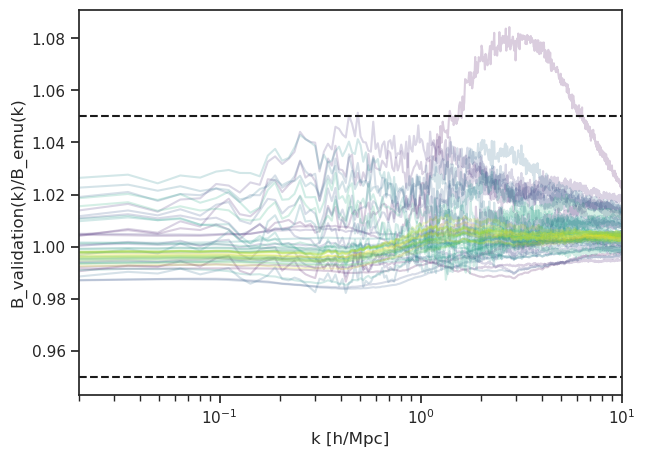

In [48]:
f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val_edges)):
    cosmo_val_edges = ccl.Cosmology(Omega_c = Omega_m_val_edges[sim_index] - 0.0223/h_val_edges[sim_index]**2,
                               Omega_b = 0.0223/h_val_edges[sim_index]**2,
                               h = h_val_edges[sim_index],
                               n_s = n_s_val_edges[sim_index],
                               A_s = A_s_val_edges[sim_index])
    
    Bk_test_val_edges = B_k_NL_CuGal(f_phi_val_edges[sim_index], cosmo_val_edges, k_arr_val_edges*cosmo_val_edges["h"], 1)

    ax.plot(k_arr_val_edges, Bk_arr_val_edges[sim_index, 0, :]/Bk_test_val_edges,color = cmap(np.linspace(0,1,len(f_phi_val_edges))[sim_index]), alpha=0.2)

ax.plot(k_arr_val, 1.05*np.ones(len(k_arr_val)), "k--")
ax.plot(k_arr_val, 0.95*np.ones(len(k_arr_val)), "k--")

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


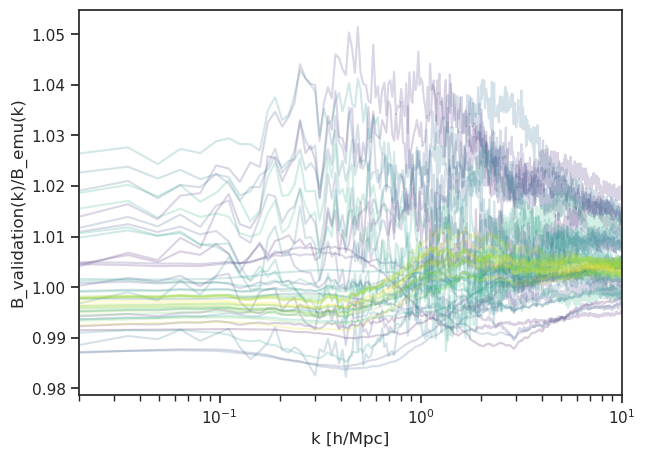

In [49]:
f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val_edges)):
    if sim_index != 1:
        cosmo_val_edges = ccl.Cosmology(Omega_c = Omega_m_val_edges[sim_index] - 0.0223/h_val_edges[sim_index]**2,
                                   Omega_b = 0.0223/h_val_edges[sim_index]**2,
                                   h = h_val_edges[sim_index],
                                   n_s = n_s_val_edges[sim_index],
                                   A_s = A_s_val_edges[sim_index])
        
        Bk_test_val_edges = B_k_NL_CuGal(f_phi_val_edges[sim_index], cosmo_val_edges, k_arr_val_edges*cosmo_val_edges["h"], 1)
    
        ax.plot(k_arr_val_edges, Bk_arr_val_edges[sim_index, 0, :]/Bk_test_val_edges,color = cmap(np.linspace(0,1,len(f_phi_val_edges))[sim_index]), alpha=0.2)

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


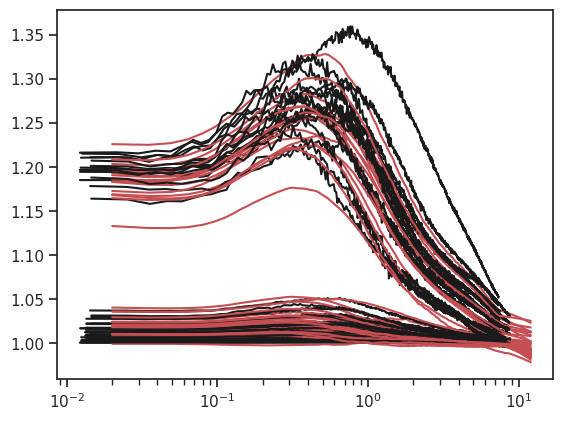

In [50]:

for sim_index in range(len(Bk_arr_val_edges)):

    cosmo_val_edges = ccl.Cosmology(Omega_c = Omega_m_val_edges[sim_index] - 0.0223/h_val_edges[sim_index]**2,
                               Omega_b = 0.0223/h_val_edges[sim_index]**2,
                               h = h_val_edges[sim_index],
                               n_s = n_s_val_edges[sim_index],
                               A_s = A_s_val_edges[sim_index])
    
    Bk_test_val_edges = B_k_NL_CuGal(f_phi_val_edges[sim_index], cosmo_val_edges, k_arr_val_edges, 1)

    plt.semilogx(k_arr_val_edges*cosmo_val_edges["h"], Bk_arr_val_edges[sim_index, 0, :], color="k")
    plt.semilogx(k_arr_val_edges, Bk_test_val_edges, color="r")

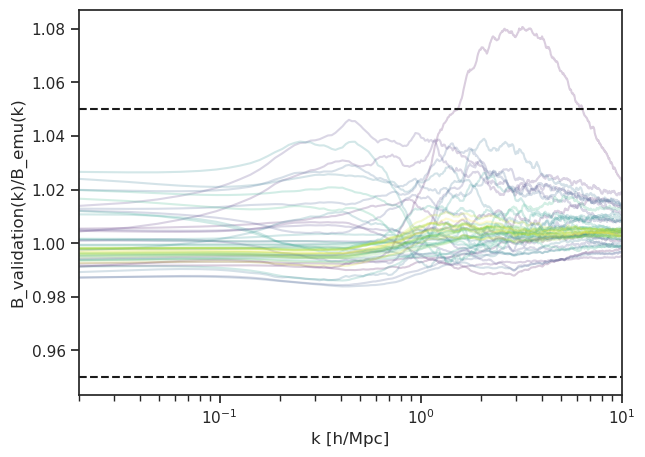

In [53]:
f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val_edges)):
    cosmo_val_edges = ccl.Cosmology(Omega_c = Omega_m_val_edges[sim_index] - 0.0223/h_val_edges[sim_index]**2,
                               Omega_b = 0.0223/h_val_edges[sim_index]**2,
                               h = h_val_edges[sim_index],
                               n_s = n_s_val_edges[sim_index],
                               A_s = A_s_val_edges[sim_index])
    
    Bk_test_val_edges = B_k_NL_CuGal(f_phi_val_edges[sim_index], cosmo_val_edges, k_arr_val_edges*cosmo_val_edges["h"], 1)

    ax.plot(k_arr_val_edges, savgol_filter(Bk_arr_val_edges[sim_index, 0, :],17,3)/Bk_test_val_edges,color = cmap(np.linspace(0,1,len(f_phi_val_edges))[sim_index]), alpha=0.2)

ax.plot(k_arr_val, 1.05*np.ones(len(k_arr_val)), "k--")
ax.plot(k_arr_val, 0.95*np.ones(len(k_arr_val)), "k--")

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")


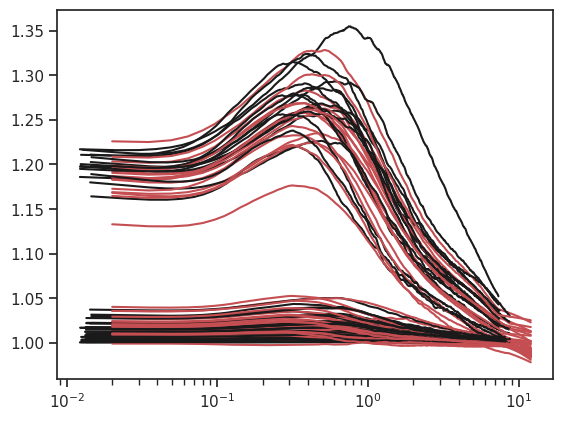

In [54]:

for sim_index in range(len(Bk_arr_val_edges)):

    cosmo_val_edges = ccl.Cosmology(Omega_c = Omega_m_val_edges[sim_index] - 0.0223/h_val_edges[sim_index]**2,
                               Omega_b = 0.0223/h_val_edges[sim_index]**2,
                               h = h_val_edges[sim_index],
                               n_s = n_s_val_edges[sim_index],
                               A_s = A_s_val_edges[sim_index])
    
    Bk_test_val_edges = B_k_NL_CuGal(f_phi_val_edges[sim_index], cosmo_val_edges, k_arr_val_edges, 1)

    plt.semilogx(k_arr_val_edges*cosmo_val_edges["h"], savgol_filter(Bk_arr_val_edges[sim_index, 0, :],17,3), color="k")
    plt.semilogx(k_arr_val_edges, Bk_test_val_edges, color="r")

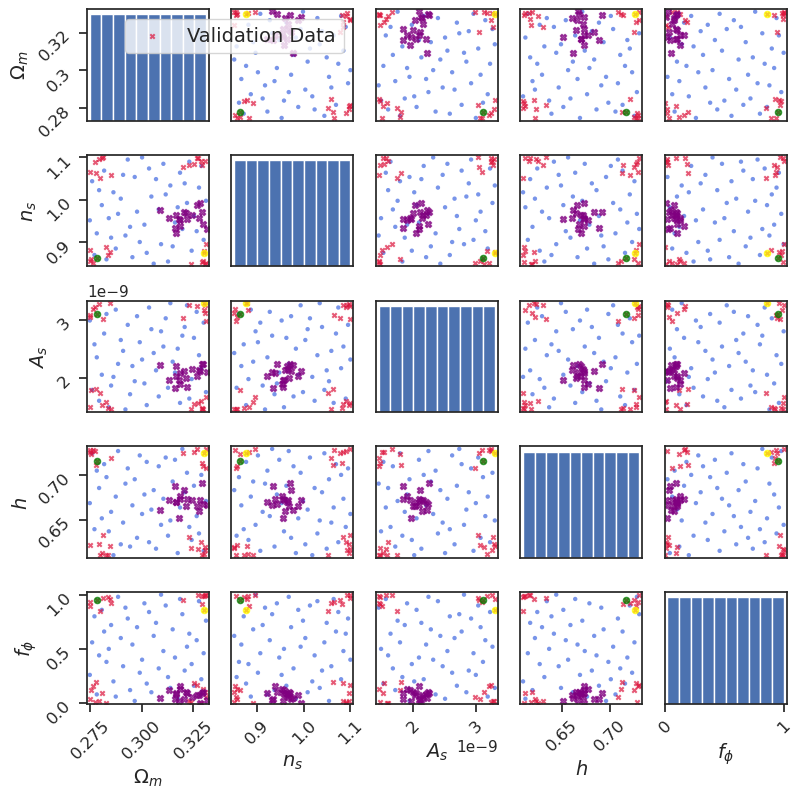

In [22]:
txt = "Validation_data/cosmo_newdesign_tracker"
hcube_emu  = np.loadtxt(txt)
txt = "Validation_data/cosmo_validation_edges"
hcube_val  = np.loadtxt(txt)

# Sample DataFrames (replace with actual data)
df_theta_emu = pd.DataFrame(hcube_emu, columns=[r'$\Omega_m$', r'$n_s$', r'$A_s$', r'$h$', r'$f_\phi$'][:len(hcube_emu)])
df_theta_val = pd.DataFrame(hcube_val, columns=[r'$\Omega_m$', r'$n_s$', r'$A_s$', r'$h$', r'$f_\phi$'][:len(hcube_val)])

# Customization options
color_emu = "royalblue"   # Color for df_theta_emu
color_val = "crimson"     # Color for df_theta_val
s = 10                    # Marker size
tick_size = 12            # Tick label size
label_size = 14           # Axis label size
tick_rotation = 45        # Rotation angle for tick labels
diag_color = "black"      # Color for diagonal histograms/KDE

# Create scatter matrix for the first dataset
scatter_matrix_fig = pd.plotting.scatter_matrix(
    df_theta_emu, 
    figsize=(8, 8), 
    color=color_emu, 
    marker='o', 
    s=s, 
    alpha=0.7,
    density_kwds={'color': diag_color, 'linewidth': 2},
)
sim_index = 23
# Overlay the second dataset
for i in range(len(df_theta_emu.columns)):
    for j in range(len(df_theta_emu.columns)):
        if i != j:  # Only apply to scatter plots, not the diagonal
            ax = scatter_matrix_fig[i, j]
            ax.scatter(df_theta_val.iloc[:, j], df_theta_val.iloc[:, i], color=color_val, marker='x', s=s, alpha=0.7, label="Validation Data")
            ax.scatter(df_theta_val.iloc[sim_index, j], df_theta_val.iloc[sim_index, i], color="yellow", marker='o', s=s*2, alpha=0.7, label="i=23")
            ax.scatter(df_theta_val.iloc[7, j], df_theta_val.iloc[7, i], color="green", marker='o', s=s*2, alpha=0.7, label="i=7")
# Customize tick labels and labels
plt.tight_layout()
for ax in plt.gcf().get_axes():
    ax.tick_params(axis="both", labelsize=tick_size, rotation=tick_rotation)
    ax.xaxis.label.set_size(label_size)
    ax.yaxis.label.set_size(label_size)

# Add legend to one of the subplots
scatter_matrix_fig[0, 1].legend(loc="upper right", fontsize=label_size)

plt.show()



In [23]:
# Load the saved array - gives Boost(i = sample point, z, k)
Bk_arr_val_edges = np.load('Validation_data/Boost_validation_edges.npy')
print(Bk_arr_val_edges.shape)
# extract data from text file - gives z and k arrays
txt_arr_val_edges = np.loadtxt("Validation_data/z_k_validation_edges.txt")

z_arr_val_edges = np.array(txt_arr_val_edges.T[0][np.isfinite(txt_arr_val_edges.T[0])])
k_arr_val_edges = np.array(txt_arr_val_edges.T[1])

print(z_arr_val_edges.shape)
print(k_arr_val_edges.shape)

# Get the parameter - for now assume only one parameter, w_m
txt = "Validation_data/cosmo_validation_edges"
hcube_val_edges  = np.loadtxt(txt).T
f_phi_val_edges = hcube_val_edges[4]
h_val_edges = hcube_val_edges[3]
Omega_m_val_edges = hcube_val_edges[0]
n_s_val_edges = hcube_val_edges[1]
A_s_val_edges = hcube_val_edges[2]



(50, 101, 768)
(101,)
(768,)


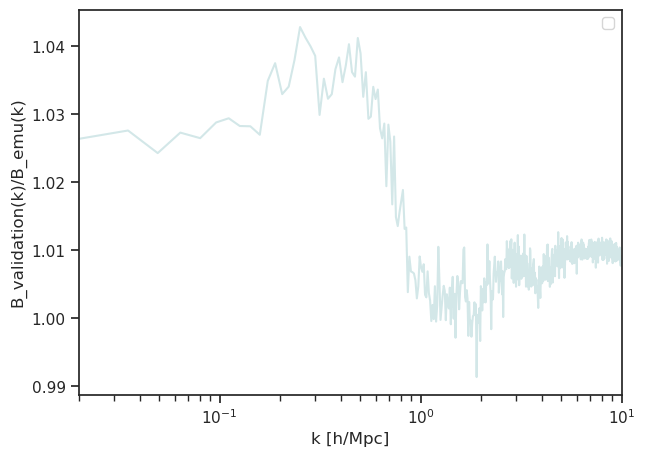

In [24]:
f, ax = plt.subplots(1,figsize=(7, 5))

cmap = matplotlib.colormaps['viridis']

sim_index = 23
cosmo_val_edges = ccl.Cosmology(Omega_c = Omega_m_val_edges[sim_index] - 0.0223/h_val_edges[sim_index]**2,
                           Omega_b = 0.0223/h_val_edges[sim_index]**2,
                           h = h_val_edges[sim_index],
                           n_s = n_s_val_edges[sim_index],
                           A_s = A_s_val_edges[sim_index])

Bk_test_val_edges = B_k_NL_CuGal(f_phi_val_edges[sim_index], cosmo_val_edges, k_arr_val_edges*cosmo_val_edges["h"], 1)

ax.plot(k_arr_val_edges, Bk_arr_val_edges[sim_index, 0, :]/Bk_test_val_edges,color = cmap(np.linspace(0,1,len(f_phi_val_edges))[sim_index]), alpha=0.2)

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")
plt.legend()
